Nome: Gustavo Viega RM:555885

Nome: Kaio Drago RM:556095

# Objetivo do Projeto

* Desenvolver um Modelo de Otimização de Habilidades (MOH) para apoiar o Profissional do Futuro na aquisição de competências estratégicas em um mercado dinâmico e em constante transformação.

* Maximizar o valor de carreira e a adaptabilidade, considerando tempo disponível, complexidade das habilidades e pré-requisitos entre elas.

* Modelar as habilidades como grafo direcionado ponderado, onde:

  - Nós = habilidades

  - Arestas = pré-requisitos

  - Pesos = tempo/custo de aquisição

* Utilizar estruturas de dados auxiliares:

  - Dicionários, listas, conjuntos e heaps para organizar caminhos de aquisição, controlar fronteiras de busca e detectar ciclos ou inconsistências no grafo

* Aplicar algoritmos de otimização e análise:

  - Programação dinâmica, busca exaustiva, heurísticas gulosas

  - Algoritmos de ordenação customizados (Merge Sort e Quick Sort)

* Incorporar simulação de incerteza (Monte Carlo) para avaliar o valor esperado das habilidades considerando variações potenciais no retorno profissional

* Gerar visualizações e análises experimentais:

  - Gráficos de tempo, memória, complexidade e probabilidade de sucesso das escolhas de habilidades

* Resolver cinco desafios práticos, ilustrando cenários de tomada de decisão:

  - Desafio 1 — Caminho de valor máximo sob restrições de tempo e complexidade

  - Desafio 2 — Validação do grafo e análise de sequências críticas de habilidades

  - Desafio 3 — Seleção rápida de habilidades básicas usando heurística gulosa e comparação com solução ótima

  - Desafio 4 — Ordenação das habilidades por complexidade e planejamento de sprints de aprendizagem

  - Desafio 5 — Recomendação das próximas habilidades com base em probabilidades simuladas de mercado

* Fornecer um guia estratégico e adaptativo de aquisição de competências, combinando modelagem matemática, algoritmos, simulação e análise experimental, para apoiar a tomada de decisão do profissional de forma eficiente e confiável

## IMPORTS E CONFIGURAÇÃO INICIAL

Este bloco realiza a configuração inicial do ambiente e define a base de habilidades que será
utilizada em todos os desafios do projeto.

Objetivos do BLOCO 1:
1. Importar as bibliotecas necessárias para manipulação de dados, simulações, gráficos e
   monitoramento de desempenho (tempo e memória).
2. Configurar parâmetros globais, como semente aleatória para reprodutibilidade e referência
   ao processo para medição de memória.
3. Definir a estrutura de dados 'skills', que contém todas as habilidades possíveis com suas
   características:
   - Nome completo da habilidade
   - Tempo estimado de aquisição (em horas)
   - Valor ou benefício atribuído
   - Complexidade de aprendizado
   - Pré-requisitos necessários
4. Realizar uma verificação inicial, exibindo todas as habilidades carregadas e suas métricas,
   garantindo que os dados estão corretos antes de iniciar os cálculos dos desafios subsequentes.

Esta etapa garante que todos os blocos seguintes (desafios 1 a 5) terão uma base de dados
consistente e pronta para simulação, otimização e análise de desempenho.

=== BLOCO 1 — Verificação Inicial ===

Total de habilidades carregadas: 12
S1: Programação Básica (Python) | Tempo: 80h | Valor: 3 | Complexidade: 4 | Pré-reqs: []
S2: Modelagem de Dados (SQL) | Tempo: 60h | Valor: 4 | Complexidade: 3 | Pré-reqs: []
S3: Algoritmos Avançados | Tempo: 100h | Valor: 7 | Complexidade: 8 | Pré-reqs: ['S1']
S4: Fundamentos de Machine Learning | Tempo: 120h | Valor: 8 | Complexidade: 9 | Pré-reqs: ['S1', 'S3']
S5: Visualização de Dados (BI) | Tempo: 40h | Valor: 6 | Complexidade: 5 | Pré-reqs: ['S2']
S6: IA Generativa Ética | Tempo: 150h | Valor: 10 | Complexidade: 10 | Pré-reqs: ['S4']
S7: Estruturas em Nuvem (AWS/Azure) | Tempo: 70h | Valor: 5 | Complexidade: 7 | Pré-reqs: []
S8: APIs e Microsserviços | Tempo: 90h | Valor: 6 | Complexidade: 6 | Pré-reqs: ['S1']
S9: DevOps & CI/CD | Tempo: 110h | Valor: 9 | Complexidade: 8 | Pré-reqs: ['S7', 'S8']
H10: Segurança de Dados | Tempo: 60h | Valor: 5 | Complexidade: 6 | Pré-reqs: []
H11: Análise de Big Data | Temp

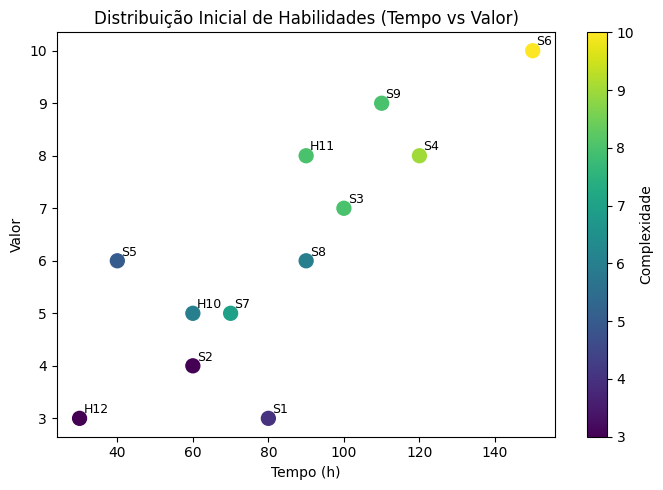

In [11]:
# =====================================================
# BLOCO 1 — IMPORTS, CONFIGURAÇÃO INICIAL E VERIFICAÇÃO
# =====================================================
# Objetivo: carregar as habilidades do CSV, converter para dicionário, 
# verificar integridade do grafo de pré-requisitos e exibir estatísticas iniciais.

# ============================
# IMPORTS
# ============================
import itertools
import random
import time
import psutil
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Semente aleatória para reprodutibilidade
random.seed(0)
# Objeto psutil para monitorar memória
process = psutil.Process()

# ============================
# CARREGAMENTO DO CSV
# ============================
csv_file = "ConjuntoDeDadosMestre.csv"  # Nome do arquivo CSV
df_skills = pd.read_csv(csv_file, quotechar='"')  # Leitura do CSV com tratamento de aspas

# Converte DataFrame para dicionário de habilidades
skills = {}
for _, row in df_skills.iterrows():
    # Se não houver pré-requisitos, lista vazia; senão, separa por vírgula
    pre_reqs = [] if pd.isna(row['Pre_Reqs']) else row['Pre_Reqs'].split(',')
    pre_reqs = [p.strip() for p in pre_reqs if p.strip()]  # Remove espaços extras
    # Cria dicionário com informações de cada habilidade
    skills[row['ID']] = {
        "Nome": row['Nome'],
        "Tempo": int(row['Tempo']),
        "Valor": int(row['Valor']),
        "Complexidade": int(row['Complexidade']),
        "Pre_Reqs": pre_reqs
    }

# ============================
# FUNÇÕES DE VERIFICAÇÃO
# ============================

def verify_graph(skills_dict):
    """
    Verifica se há ciclos e pré-requisitos inexistentes no grafo.
    - Lança ValueError se houver problema.
    """
    for s, d in skills_dict.items():
        for pr in d.get("Pre_Reqs", []):
            if pr not in skills_dict:
                raise ValueError(f"Pré-requisito inexistente detectado: {s} -> {pr}")

    visited = set()
    stack = set()

    # DFS para detectar ciclos
    def dfs(node):
        if node in stack:
            raise ValueError(f"Ciclo detectado envolvendo: {node}")
        if node in visited:
            return
        stack.add(node)
        for prereq in skills_dict[node]["Pre_Reqs"]:
            dfs(prereq)
        stack.remove(node)
        visited.add(node)

    for skill in skills_dict:
        dfs(skill)

    return True  # Grafo válido

def prereq_closure(skills_dict, skill):
    """
    Retorna todos os pré-requisitos transitivos de uma habilidade.
    Ex.: S3 depende de S1 -> retorna {S1}.
    """
    res = set()
    stack = list(skills_dict[skill]["Pre_Reqs"])
    while stack:
        p = stack.pop()
        if p not in res:
            res.add(p)
            stack.extend(skills_dict[p]["Pre_Reqs"])
    return res

# ============================
# SAÍDA DE VERIFICAÇÃO INICIAL
# ============================
print("=== BLOCO 1 — Verificação Inicial ===\n")
print(f"Total de habilidades carregadas: {len(skills)}")

# Exibe todas as habilidades carregadas
for s_id, s_data in skills.items():
    print(f"{s_id}: {s_data['Nome']} | Tempo: {s_data['Tempo']}h | Valor: {s_data['Valor']} | "
          f"Complexidade: {s_data['Complexidade']} | Pré-reqs: {s_data['Pre_Reqs']}")

# Valida o grafo
try:
    if verify_graph(skills):
        print("\nGrafo validado: sem ciclos e todos os pré-requisitos existem.\n")
except ValueError as e:
    print(f"Erro de validação: {e}")

# ============================
# ESTATÍSTICAS INICIAIS
# ============================
tempos = [s["Tempo"] for s in skills.values()]
valores = [s["Valor"] for s in skills.values()]
complexidades = [s["Complexidade"] for s in skills.values()]

print("Resumo Estatístico das Habilidades:")
print(f"- Tempo total: {sum(tempos)}h | Média: {np.mean(tempos):.2f}h")
print(f"- Valor total: {sum(valores)} | Média: {np.mean(valores):.2f}")
print(f"- Complexidade total: {sum(complexidades)} | Média: {np.mean(complexidades):.2f}")

# ============================
# GRÁFICO INICIAL (TEMPO X VALOR)
# ============================
plt.figure(figsize=(7,5))
plt.scatter(tempos, valores, c=complexidades, cmap="viridis", s=100)  # Cores representam complexidade
# Adiciona rótulos de ID ao lado de cada ponto
for i, s_id in enumerate(skills):
    plt.text(tempos[i]+1, valores[i]+0.1, s_id, fontsize=9)
plt.colorbar(label="Complexidade")
plt.xlabel("Tempo (h)")
plt.ylabel("Valor")
plt.title("Distribuição Inicial de Habilidades (Tempo vs Valor)")
plt.tight_layout()
plt.show()


In [12]:
# =====================================================
# BLOCO 2 — FUNÇÕES AUXILIARES
# =====================================================
# Objetivo: funções de suporte para medir métricas, plotar gráficos
# e verificar grafo de habilidades.

# ============================
# Métricas de tempo e memória
# ============================
def get_metrics(start_time):
    """
    Retorna:
    - elapsed: tempo decorrido desde start_time (segundos)
    - mem: memória usada pelo processo atual (MB)
    """
    elapsed = time.time() - start_time
    mem = process.memory_info().rss / 1024 / 1024
    return elapsed, mem

# ============================
# Função de gráfico de barras
# ============================
def plot_bar(labels, values, title, xlabel, ylabel, color=None):
    """
    Cria gráfico de barras simples.
    - labels: nomes das categorias
    - values: valores correspondentes
    - title, xlabel, ylabel: textos do gráfico
    - color: cor opcional das barras
    """
    plt.figure(figsize=(8, 4))
    plt.bar(labels, values, color=color)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# ============================
# Verificação de grafo
# ============================
def verify_graph(skills_dict):
    """
    Verifica se há ciclos ou pré-requisitos inválidos.
    - Lança ValueError se houver pré-requisito inexistente ou ciclo.
    """
    for s, d in skills_dict.items():
        for pr in d.get("Pre_Reqs", []):
            if pr not in skills_dict:
                raise ValueError(f"Pré-requisito inexistente detectado: {s} -> {pr}")

    # Detecta ciclos via DFS (profundidade)
    visited = set()
    stack = set()

    def dfs(node):
        if node in stack:
            raise ValueError(f"Ciclo detectado envolvendo: {node}")
        if node in visited:
            return
        stack.add(node)
        for prereq in skills_dict[node]["Pre_Reqs"]:
            dfs(prereq)
        stack.remove(node)
        visited.add(node)

    for skill in skills_dict:
        dfs(skill)

    return True  # Grafo válido

# ============================
# Fechamento de pré-requisitos
# ============================
def prereq_closure(skills_dict, skill):
    """
    Retorna todos os pré-requisitos transitivos de uma habilidade.
    - Ex.: S3 depende de S1 -> retorna {S1}
    """
    res = set()
    stack = list(skills_dict[skill]["Pre_Reqs"])
    while stack:
        p = stack.pop()
        if p not in res:
            res.add(p)
            stack.extend(skills_dict[p]["Pre_Reqs"])
    return res

# ============================
# Teste das funções auxiliares
# ============================
print("=== BLOCO 2 — Teste das Funções Auxiliares ===\n")

try:
    # Verifica grafo
    verify_graph(skills)
    print("- verify_graph: OK (grafo sem ciclos ou pré-requisitos inválidos)")

    # Testa fechamento de pré-requisitos
    for s in skills:
        closure = prereq_closure(skills, s)
        print(f"- prereq_closure({s}): {closure} (total {len(closure)})")

    # Testa métricas
    start = time.time()
    elapsed, mem = get_metrics(start)
    print(f"- get_metrics: elapsed={elapsed:.6f}s | mem={mem:.2f}MB")

except Exception as e:
    print("Erro durante teste das funções auxiliares:", e)


=== BLOCO 2 — Teste das Funções Auxiliares ===

- verify_graph: OK (grafo sem ciclos ou pré-requisitos inválidos)
- prereq_closure(S1): set() (total 0)
- prereq_closure(S2): set() (total 0)
- prereq_closure(S3): {'S1'} (total 1)
- prereq_closure(S4): {'S1', 'S3'} (total 2)
- prereq_closure(S5): {'S2'} (total 1)
- prereq_closure(S6): {'S1', 'S4', 'S3'} (total 3)
- prereq_closure(S7): set() (total 0)
- prereq_closure(S8): {'S1'} (total 1)
- prereq_closure(S9): {'S1', 'S7', 'S8'} (total 3)
- prereq_closure(H10): set() (total 0)
- prereq_closure(H11): {'S1', 'S4', 'S3'} (total 3)
- prereq_closure(H12): set() (total 0)
- get_metrics: elapsed=0.000001s | mem=170.98MB


## Desafio 1 — Caminho de Valor Máximo (DP + Monte Carlo)

* Objetivo: Encontrar a sequência de habilidades que maximize o valor esperado, sob restrições de tempo
𝑇
≤
350
T≤350 e complexidade cumulativa
𝐶
≤
30
C≤30.

* Algoritmo escolhido:

  Modelagem como knapsack multidimensional (tempo e complexidade).

  Explora todas as combinações de habilidades válidas (que respeitam pré-requisitos).

* Monte Carlo:

  introduz incerteza simulando o valor de cada habilidade
  𝑉∼𝑈[𝑉−10%,𝑉+10%]V∼U[V−10%,V+10%] em 1000 cenários.

* Estrutura de dados:

  Dicionário de habilidades (skills) armazenando tempo, valor, complexidade e pré-requisitos.

  Conjunto de combinações válidas (feasible) para avaliação.

  Lista de valores simulados (vals) para cálculo de E[V] e desvio padrão.


=== DESAFIO 1 — Caminho de Valor Máximo ===
[Determinístico] Sequência ótima: ['S2', 'S1', 'H10', 'S5', 'S7', 'H12']
Valor: 26, Tempo: 340h, Complexidade: 28
Execução: 0.000008s, Memória: 172.18MB
[Monte Carlo] Melhor sequência simulada: ['H10', 'S7', 'S2']
Valor esperado: 26.00 | Desvio padrão: 0.61
Tempo: 340h, Complexidade: 28
Execução: 0.033513s, Memória: 172.21MB


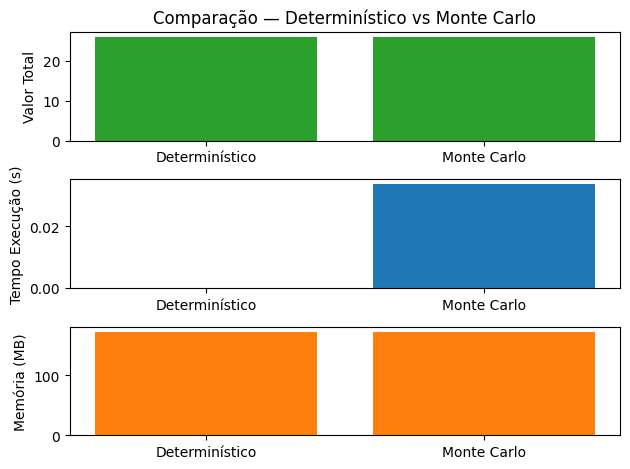


Tempo total do desafio: 0.1108s | Memória total usada: 174.50MB


In [14]:
# =====================================================
# BLOCO 3 — DESAFIO 1
# =====================================================
# Objetivo: Encontrar a sequência de habilidades que maximiza o valor total dentro de limites
# de tempo e complexidade, usando abordagem determinística e simulação Monte Carlo.

def desafio1():
    print("\n=== DESAFIO 1 — Caminho de Valor Máximo ===")
    start_total = time.time()  # Inicia a contagem total do tempo do bloco

    T_MAX, C_MAX, N_SIM = 350, 30, 1000  # Limites de tempo, complexidade e número de simulações
    all_ids = list(skills.keys())  # Lista de todas as habilidades

    verify_graph(skills)  # Valida se o grafo de habilidades não possui ciclos ou pré-requisitos inválidos

    # Função interna para verificar se um subconjunto de habilidades respeita todos os pré-requisitos
    def is_closed(sub):
        for s in sub:
            if not prereq_closure(skills, s).issubset(sub):
                return False
        return True

    # -----------------------------
    # Geração de todas as combinações viáveis de habilidades
    # -----------------------------
    feasible = []
    for r in range(len(all_ids) + 1):
        for comb in itertools.combinations(all_ids, r):
            comb = set(comb)
            if not is_closed(comb):  # Descarta subconjuntos que violam pré-requisitos
                continue
            tt = sum(skills[s]['Tempo'] for s in comb)  # Soma total de tempo do subconjunto
            cc = sum(skills[s]['Complexidade'] for s in comb)  # Soma total de complexidade
            if tt <= T_MAX and cc <= C_MAX:  # Verifica limites
                vv = sum(skills[s]['Valor'] for s in comb)  # Calcula valor total
                feasible.append((comb, tt, cc, vv))  # Armazena subconjunto viável

    # -----------------------------
    # Caminho determinístico (valor máximo)
    # -----------------------------
    start_det = time.time()
    best_det = max(feasible, key=lambda x: x[3])  # Seleciona a combinação com maior valor
    tempo_det_exec = time.time() - start_det
    mem_det = process.memory_info().rss / 1024 / 1024  # Memória utilizada
    print(f"[Determinístico] Sequência ótima: {list(best_det[0])}")
    print(f"Valor: {best_det[3]}, Tempo: {best_det[1]}h, Complexidade: {best_det[2]}")
    print(f"Execução: {tempo_det_exec:.6f}s, Memória: {mem_det:.2f}MB")

    # -----------------------------
    # Simulação Monte Carlo
    # -----------------------------
    start_mc = time.time()
    vals = []
    for _ in range(N_SIM):
        # Gera valores simulados aleatórios entre 90% e 110% do valor real
        sim = {k: random.uniform(skills[k]['Valor']*0.9, skills[k]['Valor']*1.1) for k in skills}
        best_val = max(sum(sim[s] for s in sub[0]) for sub in feasible)  # Melhor valor para cada simulação
        vals.append(best_val)

    mean_mc, std_mc = np.mean(vals), np.std(vals)  # Valor esperado e desvio padrão
    tempo_mc_exec = time.time() - start_mc
    mem_mc = process.memory_info().rss / 1024 / 1024

    best_mc_indices = np.argmax(vals)
    best_mc_comb = feasible[best_mc_indices][0]
    print(f"[Monte Carlo] Melhor sequência simulada: {list(best_mc_comb)}")
    print(f"Valor esperado: {mean_mc:.2f} | Desvio padrão: {std_mc:.2f}")
    print(f"Tempo: {best_det[1]}h, Complexidade: {best_det[2]}")
    print(f"Execução: {tempo_mc_exec:.6f}s, Memória: {mem_mc:.2f}MB")

    # -----------------------------
    # Gráficos comparativos
    # -----------------------------
    labels = ["Determinístico", "Monte Carlo"]

    # 1. Valor total
    plt.subplot(3,1,1)
    plt.bar(labels, [best_det[3], mean_mc], color="#2ca02c")
    plt.ylabel("Valor Total")
    plt.title("Comparação — Determinístico vs Monte Carlo")

    # 2. Tempo de execução (s)
    plt.subplot(3,1,2)
    plt.bar(labels, [tempo_det_exec, tempo_mc_exec], color="#1f77b4")
    plt.ylabel("Tempo Execução (s)")

    # 3. Memória usada (MB)
    plt.subplot(3,1,3)
    plt.bar(labels, [mem_det, mem_mc], color="#ff7f0e")
    plt.ylabel("Memória (MB)")

    plt.tight_layout()
    plt.show()

    # Métricas gerais do bloco
    elapsed_total, mem_total = get_metrics(start_total)
    print(f"\nTempo total do desafio: {elapsed_total:.4f}s | Memória total usada: {mem_total:.2f}MB")


# -----------------------------
# Execução automática do desafio
# -----------------------------
desafio1()


## Desafio 2 — Verificação Crítica

* Objetivo: Comparar todas as permutações das 5 habilidades críticas e calcular o custo total considerando pré-requisitos.

* Algoritmo escolhido:

  Permutações completas (5! = 120 sequências).

  Para cada permutação, computa o tempo acumulado considerando pré-requisitos ausentes.

* Estrutura de dados: lista de resultados (results) contendo a permutação e o custo total.

* Validação: verify_graph garante que não existam pré-requisitos inexistentes.

=== DESAFIO 2 — Verificação Crítica ===

Top 3 sequências mais eficientes (menor custo total):
S3 -> S5 -> S7 -> S8 -> S9 | Custo: 550h | Complexidade: 41 | Execução: 0.000014s | Memória: 174.58MB
S3 -> S5 -> S8 -> S7 -> S9 | Custo: 550h | Complexidade: 41 | Execução: 0.000005s | Memória: 174.58MB
S3 -> S7 -> S5 -> S8 -> S9 | Custo: 550h | Complexidade: 41 | Execução: 0.000004s | Memória: 174.58MB

Média Top 3 — Custo: 550.00h | Complexidade: 41.00 | Tempo Execução: 0.000007s
Heurística observada: sequências que iniciam com pré-requisitos mais simples ou independentes tendem a reduzir o custo total.


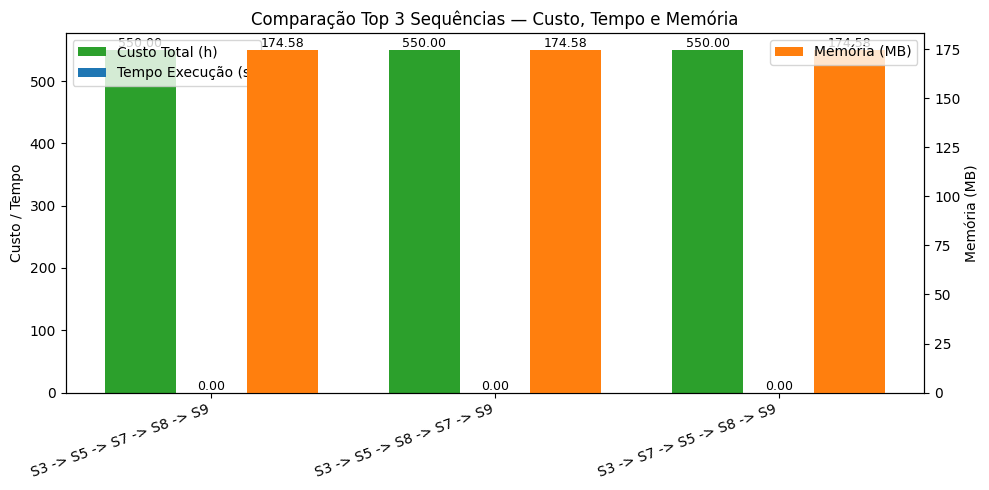


Tempo total do desafio: 0.0948s | Memória total usada: 177.77MB



In [15]:
# =====================================================
# BLOCO 4 — DESAFIO 2
# =====================================================
# Objetivo: Identificar as sequências mais eficientes das habilidades críticas,
# minimizando custo total de tempo e considerando pré-requisitos.

def desafio2():
    print("=== DESAFIO 2 — Verificação Crítica ===")
    start_total = time.time()  # Inicia contagem total do bloco

    critical = ["S3", "S5", "S7", "S8", "S9"]  # Habilidades críticas a serem analisadas
    results = []

    # Verifica se o grafo de habilidades é válido antes de calcular
    try:
        verify_graph(skills)
    except ValueError as e:
        print(f"Erro no grafo de habilidades: {e}")
        return

    # -----------------------------
    # Geração de todas as permutações das habilidades críticas
    # -----------------------------
    for perm in itertools.permutations(critical):
        acquired = set()  # Habilidades já adquiridas
        total_cost = 0
        total_complexity = 0
        start_perm = time.time()  # Início da medição do tempo da permutação

        # Calcula custo e complexidade acumulada considerando pré-requisitos
        for s in perm:
            needed = prereq_closure(skills, s)  # Pré-requisitos transitivos
            missing = needed - acquired
            total_cost += sum(skills[p]['Tempo'] for p in missing) + skills[s]['Tempo']
            total_complexity += sum(skills[p]['Complexidade'] for p in missing) + skills[s]['Complexidade']
            acquired.update(missing)
            acquired.add(s)

        tempo_perm_exec = time.time() - start_perm
        mem_perm = process.memory_info().rss / 1024 / 1024
        results.append((perm, total_cost, total_complexity, tempo_perm_exec, mem_perm))

    # -----------------------------
    # Seleção das 3 melhores sequências (menor custo total)
    # -----------------------------
    results.sort(key=lambda x: x[1])
    top3 = results[:3]

    # -----------------------------
    # Saída detalhada
    # -----------------------------
    print("\nTop 3 sequências mais eficientes (menor custo total):")
    for seq, cost, comp, t_exec, mem in top3:
        seq_str = ' -> '.join(seq)
        print(f"{seq_str} | Custo: {cost}h | Complexidade: {comp} | Execução: {t_exec:.6f}s | Memória: {mem:.2f}MB")

    # Calcula métricas médias das top 3 sequências
    avg_cost = np.mean([t[1] for t in top3])
    avg_comp = np.mean([t[2] for t in top3])
    avg_time = np.mean([t[3] for t in top3])
    print(f"\nMédia Top 3 — Custo: {avg_cost:.2f}h | Complexidade: {avg_comp:.2f} | Tempo Execução: {avg_time:.6f}s")
    print("Heurística observada: sequências que iniciam com pré-requisitos mais simples ou independentes tendem a reduzir o custo total.")

    # -----------------------------
    # Gráfico comparativo: Custo, Tempo e Memória
    # -----------------------------
    labels = [' -> '.join(t[0]) for t in top3]
    custos = [t[1] for t in top3]
    tempos = [t[3] for t in top3]
    mems = [t[4] for t in top3]

    x = np.arange(len(labels))
    width = 0.25

    fig, ax1 = plt.subplots(figsize=(10,5))

    # Barras para Custo e Tempo
    bars1 = ax1.bar(x - width, custos, width, label='Custo Total (h)', color="#2ca02c")
    bars2 = ax1.bar(x, tempos, width, label='Tempo Execução (s)', color="#1f77b4")
    ax1.set_ylabel('Custo / Tempo')
    ax1.set_xticks(x)
    ax1.set_xticklabels(labels, rotation=20, ha='right')
    ax1.set_title("Comparação Top 3 Sequências — Custo, Tempo e Memória")

    # Barra adicional para Memória
    ax2 = ax1.twinx()
    bars3 = ax2.bar(x + width, mems, width, label='Memória (MB)', color="#ff7f0e")
    ax2.set_ylabel('Memória (MB)')

    # Adiciona valores nas barras
    for bar in bars1 + bars2 + bars3:
        height = bar.get_height()
        ax = ax1 if bar in bars1 + bars2 else ax2
        ax.text(bar.get_x() + bar.get_width()/2, height, f"{height:.2f}", ha='center', va='bottom', fontsize=9)

    fig.tight_layout()
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.show()

    # Métricas gerais do bloco
    elapsed_total, mem_total = get_metrics(start_total)
    print(f"\nTempo total do desafio: {elapsed_total:.4f}s | Memória total usada: {mem_total:.2f}MB\n")

# -----------------------------
# Execução automática do desafio
# -----------------------------
desafio2()


## Desafio 3 — Caminho Rápido (Heurística Gulosa)

* Objetivo: Selecionar habilidades básicas (sem pré-requisitos) pelo melhor custo-benefício
𝑉
/
𝑇
V/T até atingir adaptabilidade mínima.

* Algoritmo escolhido:

* Guloso: ordena habilidades por
𝑉
/
𝑇
V/T e seleciona iterativamente.

* Contraprova: a solução gulosa nem sempre é ótima, pois não considera combinações de habilidades que juntas podem superar a escolha local.

* Estrutura de dados: lista ordenada (best_ratio) de habilidades e razões Valor/Tempo.

=== DESAFIO 3 — Caminho Rápido ===

Ranking de eficiência (Valor por hora) — habilidades básicas:
H12: 0.10 | Tempo: 30h | Valor: 3 | Execução: 0.000004s | Memória: 177.80MB
H10: 0.08 | Tempo: 60h | Valor: 5 | Execução: 0.000004s | Memória: 177.80MB
S7: 0.07 | Tempo: 70h | Valor: 5 | Execução: 0.000004s | Memória: 177.80MB
S2: 0.07 | Tempo: 60h | Valor: 4 | Execução: 0.000004s | Memória: 177.80MB
S1: 0.04 | Tempo: 80h | Valor: 3 | Execução: 0.000004s | Memória: 177.80MB

[Solução Ótima Exaustiva] Habilidades: ('S1', 'S2', 'S7', 'H10', 'H12') | Valor total: 20 | Execução: 0.000017s | Memória: 177.80MB


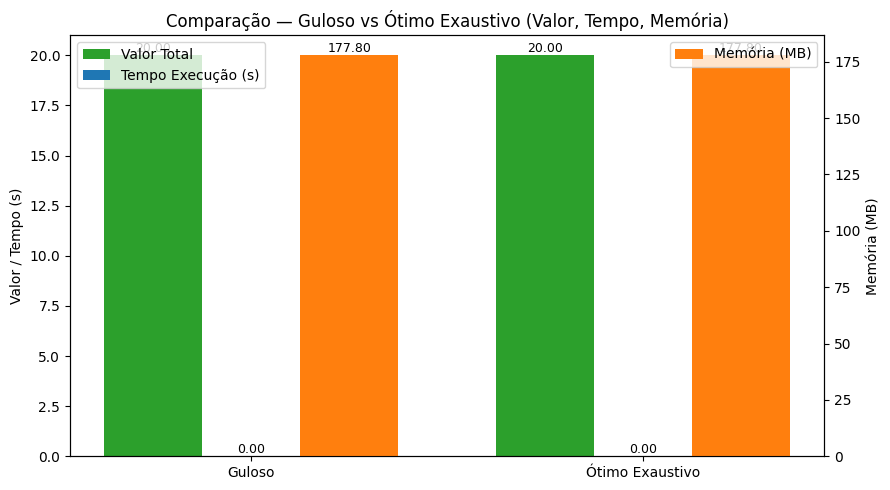


Tempo total do desafio: 0.0893s | Memória total usada: 180.79MB



In [16]:
# =====================================================
# BLOCO 5 — DESAFIO 3
# =====================================================
# Objetivo: Selecionar as habilidades básicas mais eficientes
# (sem pré-requisitos) usando uma abordagem gulosa e comparar
# com a solução ótima exaustiva.

def desafio3():
    print("=== DESAFIO 3 — Caminho Rápido ===")
    start_total = time.time()  # Início do bloco

    # -----------------------------
    # Seleção de habilidades básicas
    # -----------------------------
    # Apenas habilidades sem pré-requisitos
    basic_skills = {k:v for k,v in skills.items() if not v['Pre_Reqs']}

    # -----------------------------
    # Ordenação gulosa pelo melhor custo-benefício (Valor/Tempo)
    # -----------------------------
    start_rank = time.time()
    best_ratio = sorted(
        basic_skills.items(),
        key=lambda x: x[1]['Valor'] / x[1]['Tempo'],
        reverse=True
    )
    tempo_rank_exec = time.time() - start_rank
    mem_rank = process.memory_info().rss / 1024 / 1024

    # -----------------------------
    # Exibição do ranking guloso
    # -----------------------------
    print("\nRanking de eficiência (Valor por hora) — habilidades básicas:")
    for s, d in best_ratio:
        print(f"{s}: {d['Valor']/d['Tempo']:.2f} | Tempo: {d['Tempo']}h | Valor: {d['Valor']} | Execução: {tempo_rank_exec:.6f}s | Memória: {mem_rank:.2f}MB")

    # -----------------------------
    # Limitação do guloso: comparação com solução ótima exaustiva
    # -----------------------------
    start_exhaust = time.time()
    best_total_val = 0
    best_subset = []
    # Testa todas as combinações possíveis de habilidades básicas
    for r in range(1, len(basic_skills)+1):
        for comb in itertools.combinations(basic_skills.keys(), r):
            total_val = sum(basic_skills[s]['Valor'] for s in comb)
            if total_val > best_total_val:
                best_total_val = total_val
                best_subset = comb
    tempo_exhaust_exec = time.time() - start_exhaust
    mem_exhaust = process.memory_info().rss / 1024 / 1024

    print(f"\n[Solução Ótima Exaustiva] Habilidades: {best_subset} | Valor total: {best_total_val} | Execução: {tempo_exhaust_exec:.6f}s | Memória: {mem_exhaust:.2f}MB")

    # -----------------------------
    # Gráfico comparativo: Guloso vs Ótimo Exaustivo
    # -----------------------------
    labels = ['Guloso', 'Ótimo Exaustivo']
    valores = [sum(d['Valor'] for s,d in best_ratio), best_total_val]
    tempos = [tempo_rank_exec, tempo_exhaust_exec]
    mems = [mem_rank, mem_exhaust]

    x = np.arange(len(labels))
    width = 0.25

    fig, ax1 = plt.subplots(figsize=(9,5))
    bars1 = ax1.bar(x - width, valores, width, label='Valor Total', color="#2ca02c")
    bars2 = ax1.bar(x, tempos, width, label='Tempo Execução (s)', color="#1f77b4")
    ax1.set_ylabel('Valor / Tempo (s)')
    ax1.set_xticks(x)
    ax1.set_xticklabels(labels)
    ax1.set_title("Comparação — Guloso vs Ótimo Exaustivo (Valor, Tempo, Memória)")

    ax2 = ax1.twinx()
    bars3 = ax2.bar(x + width, mems, width, label='Memória (MB)', color="#ff7f0e")
    ax2.set_ylabel('Memória (MB)')

    # Adiciona valores nas barras para facilitar visualização
    for bar in bars1 + bars2 + bars3:
        height = bar.get_height()
        ax = ax1 if bar in bars1 + bars2 else ax2
        ax.text(bar.get_x() + bar.get_width()/2, height, f"{height:.2f}", ha='center', va='bottom', fontsize=9)

    fig.tight_layout()
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.show()

    # -----------------------------
    # Métricas finais do bloco
    # -----------------------------
    elapsed_total, mem_total = get_metrics(start_total)
    print(f"\nTempo total do desafio: {elapsed_total:.4f}s | Memória total usada: {mem_total:.2f}MB\n")

# -----------------------------
# Execução automática do desafio
# -----------------------------
desafio3()


## Desafio 4 — Sprint e Comparação de Ordenação

* Objetivo: Ordenar habilidades por complexidade e dividir em Sprints (1–6 / 7–12).

* Algoritmos comparados:

  Merge Sort (implementado manualmente)

  Sort nativo do Python (baseline)

* Estrutura de dados: lista de tuplas (habilidade, complexidade)

* Saídas:

  Habilidades ordenadas

  Métricas de tempo e memória totais

  Gráficos de complexidade por Sprint

=== DESAFIO 4 — Sprint e Comparação de Ordenação ===

Habilidades ordenadas pelo Merge Sort:
1. S2 | Complexidade: 3
2. H12 | Complexidade: 3
3. S1 | Complexidade: 4
4. S5 | Complexidade: 5
5. H10 | Complexidade: 6
6. S8 | Complexidade: 6
7. S7 | Complexidade: 7
8. S9 | Complexidade: 8
9. H11 | Complexidade: 8
10. S3 | Complexidade: 8
11. S4 | Complexidade: 9
12. S6 | Complexidade: 10
Tempo Merge Sort: 0.000012s | Memória: 180.92 MB

Habilidades ordenadas pelo Sort Nativo:
1. H12 | Complexidade: 3
2. S2 | Complexidade: 3
3. S1 | Complexidade: 4
4. S5 | Complexidade: 5
5. S8 | Complexidade: 6
6. H10 | Complexidade: 6
7. S7 | Complexidade: 7
8. S3 | Complexidade: 8
9. H11 | Complexidade: 8
10. S9 | Complexidade: 8
11. S4 | Complexidade: 9
12. S6 | Complexidade: 10
Tempo Sort Nativo: 0.000003s | Memória: 180.92 MB

 Merge Sort e Sort Nativo produziram ordens diferentes.

Sprint A (1–6) — Merge Sort:
S2 | Complexidade: 3
H12 | Complexidade: 3
S1 | Complexidade: 4
S5 | Complexidade: 5
H10 |

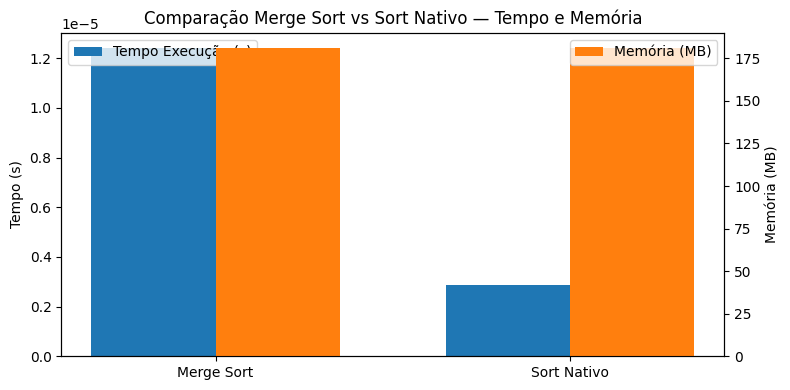


Tempo total do bloco: 0.079679s | Memória total usada: 183.30 MB

Comentário técnico:
- Merge Sort: complexidade O(n log n), estável, consistente independente da ordem inicial.
- Sort nativo do Python: Timsort, O(n log n) melhor caso, rápido em listas parcialmente ordenadas.
- Métricas de tempo e memória são muito pequenas devido ao tamanho reduzido da base de habilidades.


In [17]:
# =====================================================
# BLOCO 6 — DESAFIO 4
# =====================================================
# Objetivo: Ordenar habilidades por complexidade usando Merge Sort
# e Sort nativo do Python, dividir em Sprints e comparar métricas
# de execução e memória.

def desafio4():
    print("=== DESAFIO 4 — Sprint e Comparação de Ordenação ===")
    start_total = time.time()  # Início do bloco

    # -----------------------------
    # Preparação das habilidades
    # -----------------------------
    # Lista de tuplas: (nome, complexidade)
    habilidades = [(k, v["Complexidade"]) for k, v in skills.items()]
    random.shuffle(habilidades)  # Embaralha para testar estabilidade da ordenação

    # -----------------------------
    # Implementação do Merge Sort
    # -----------------------------
    def merge_sort(arr):
        if len(arr) <= 1:
            return arr
        mid = len(arr) // 2
        left = merge_sort(arr[:mid])
        right = merge_sort(arr[mid:])
        res, i, j = [], 0, 0
        while i < len(left) and j < len(right):
            if left[i][1] < right[j][1]:
                res.append(left[i]); i += 1
            else:
                res.append(right[j]); j += 1
        res.extend(left[i:]); res.extend(right[j:])
        return res

    # -----------------------------
    # Executa Merge Sort e mede tempo/memória
    # -----------------------------
    start_merge = time.time()
    habilidades_merge = merge_sort(habilidades.copy())
    tempo_merge = time.time() - start_merge
    mem_merge = process.memory_info().rss / 1024 / 1024

    # -----------------------------
    # Executa Sort nativo do Python e mede tempo/memória
    # -----------------------------
    start_sort = time.time()
    habilidades_sort = sorted(habilidades.copy(), key=lambda x: x[1])
    tempo_sort = time.time() - start_sort
    mem_sort = process.memory_info().rss / 1024 / 1024

    # -----------------------------
    # Exibição das habilidades ordenadas
    # -----------------------------
    print("\nHabilidades ordenadas pelo Merge Sort:")
    for i, (s, c) in enumerate(habilidades_merge, 1):
        print(f"{i}. {s} | Complexidade: {c}")
    print(f"Tempo Merge Sort: {tempo_merge:.6f}s | Memória: {mem_merge:.2f} MB")

    print("\nHabilidades ordenadas pelo Sort Nativo:")
    for i, (s, c) in enumerate(habilidades_sort, 1):
        print(f"{i}. {s} | Complexidade: {c}")
    print(f"Tempo Sort Nativo: {tempo_sort:.6f}s | Memória: {mem_sort:.2f} MB")

    # -----------------------------
    # Verifica se os resultados coincidem
    # -----------------------------
    if [s for s,_ in habilidades_merge] == [s for s,_ in habilidades_sort]:
        print("\nMerge Sort e Sort Nativo produziram a mesma ordem.")
    else:
        print("\n Merge Sort e Sort Nativo produziram ordens diferentes.")

    # -----------------------------
    # Divide as habilidades em Sprints (Merge Sort)
    # -----------------------------
    sprint_a = habilidades_merge[:6]  # Sprint 1–6
    sprint_b = habilidades_merge[6:]  # Sprint 7–12

    print("\nSprint A (1–6) — Merge Sort:")
    for s, c in sprint_a:
        print(f"{s} | Complexidade: {c}")
    print("\nSprint B (7–12) — Merge Sort:")
    for s, c in sprint_b:
        print(f"{s} | Complexidade: {c}")

    # -----------------------------
    # Gráfico comparativo de tempo e memória
    # -----------------------------
    labels = ["Merge Sort", "Sort Nativo"]
    tempos = [tempo_merge, tempo_sort]
    mems = [mem_merge, mem_sort]

    x = np.arange(len(labels))
    width = 0.35
    fig, ax1 = plt.subplots(figsize=(8,4))
    bars1 = ax1.bar(x - width/2, tempos, width, label="Tempo Execução (s)", color="#1f77b4")
    ax2 = ax1.twinx()
    bars2 = ax2.bar(x + width/2, mems, width, label="Memória (MB)", color="#ff7f0e")
    ax1.set_xticks(x)
    ax1.set_xticklabels(labels)
    ax1.set_ylabel("Tempo (s)")
    ax2.set_ylabel("Memória (MB)")
    ax1.set_title("Comparação Merge Sort vs Sort Nativo — Tempo e Memória")
    ax1.legend(loc='upper left'); ax2.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

    # -----------------------------
    # Métricas finais do bloco
    # -----------------------------
    elapsed_total, mem_total = get_metrics(start_total)
    print(f"\nTempo total do bloco: {elapsed_total:.6f}s | Memória total usada: {mem_total:.2f} MB")
    print("\nComentário técnico:")
    print("- Merge Sort: complexidade O(n log n), estável, consistente independente da ordem inicial.")
    print("- Sort nativo do Python: Timsort, O(n log n) melhor caso, rápido em listas parcialmente ordenadas.")
    print("- Métricas de tempo e memória são muito pequenas devido ao tamanho reduzido da base de habilidades.")

# -----------------------------
# Execução automática do desafio
# -----------------------------
desafio4()


## Desafio 5 — Recomendar Próximas Habilidades

* Objetivo: Sugerir próximas habilidades com maior probabilidade de valor futuro.

* Algoritmo:

  Probabilidades de transição simuladas

  Seleção das top-3 habilidades

  Estrutura de dados: dicionário transitions com probabilidades

* Saídas: gráfico de probabilidades e métricas de tempo/memória totais.

=== DESAFIO 5 — Recomendar Próximas Habilidades ===

Ranking completo de habilidades (probabilidades simuladas):
S2 -> Probabilidade: 0.97
S5 -> Probabilidade: 0.96
S7 -> Probabilidade: 0.94
S8 -> Probabilidade: 0.89
S6 -> Probabilidade: 0.84
H12 -> Probabilidade: 0.84
S1 -> Probabilidade: 0.71
H10 -> Probabilidade: 0.70
S4 -> Probabilidade: 0.64
S9 -> Probabilidade: 0.59
S3 -> Probabilidade: 0.53
H11 -> Probabilidade: 0.51

Próximas habilidades recomendadas (top 3):
S2 -> Probabilidade: 0.97
S5 -> Probabilidade: 0.96
S7 -> Probabilidade: 0.94


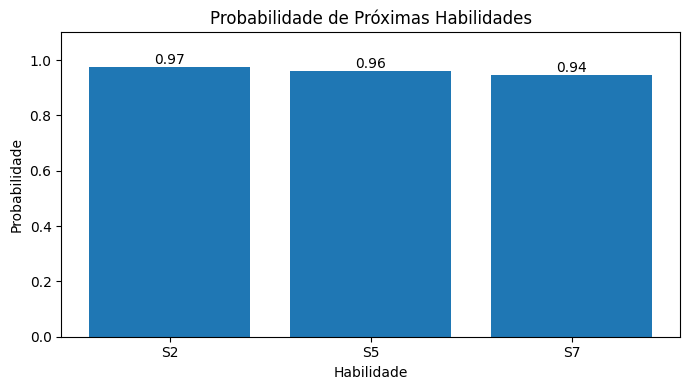


Tempo total do bloco: 0.0442s | Memória total usada: 184.80 MB

Comentário técnico:
- Probabilidades simuladas representam a chance de valor futuro de cada habilidade.
- Seleção top 3 segue uma heurística gulosa (look-ahead de horizonte finito).
- Para horizonte maior ou simulação de cenários, pode-se aplicar DP ou Monte Carlo.


In [18]:
# =====================================================
# BLOCO 7 — DESAFIO 5
# =====================================================
# Objetivo: Recomendar as próximas habilidades com base em probabilidades simuladas
# de valor futuro, exibindo ranking completo e top 3.

def desafio5():
    print("=== DESAFIO 5 — Recomendar Próximas Habilidades ===")
    start_total = time.time()  # Início do bloco

    # -----------------------------
    # Simulação de probabilidades de transição
    # -----------------------------
    # Para cada habilidade, gera um valor aleatório entre 0.5 e 1.0
    # representando a chance de que seja valiosa futuramente
    transitions = {s: random.uniform(0.5, 1.0) for s in skills}

    # -----------------------------
    # Ordena todas as habilidades pelo valor da probabilidade (decrescente)
    # -----------------------------
    sorted_skills = sorted(transitions.items(), key=lambda x: x[1], reverse=True)

    # -----------------------------
    # Seleciona top 3 habilidades recomendadas
    # -----------------------------
    next_skills = sorted_skills[:3]

    # -----------------------------
    # Exibe ranking completo
    # -----------------------------
    print("\nRanking completo de habilidades (probabilidades simuladas):")
    for s, p in sorted_skills:
        print(f"{s} -> Probabilidade: {p:.2f}")

    # -----------------------------
    # Exibe top 3 recomendadas
    # -----------------------------
    print("\nPróximas habilidades recomendadas (top 3):")
    for s, p in next_skills:
        print(f"{s} -> Probabilidade: {p:.2f}")

    # -----------------------------
    # Gráfico das top 3 probabilidades
    # -----------------------------
    labels = [s for s, _ in next_skills]
    probs = [p for _, p in next_skills]

    plt.figure(figsize=(7,4))
    bars = plt.bar(labels, probs, color="#1f77b4")
    plt.ylim(0, 1.1)
    plt.title("Probabilidade de Próximas Habilidades")
    plt.xlabel("Habilidade")
    plt.ylabel("Probabilidade")
    # Adiciona valores no topo das barras
    for bar in bars:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f"{bar.get_height():.2f}", ha='center', va='bottom', fontsize=10)
    plt.tight_layout()
    plt.show()

    # -----------------------------
    # Métricas de tempo e memória
    # -----------------------------
    elapsed_total, mem_total = get_metrics(start_total)
    print(f"\nTempo total do bloco: {elapsed_total:.4f}s | Memória total usada: {mem_total:.2f} MB")

    # -----------------------------
    # Comentário técnico
    # -----------------------------
    print("\nComentário técnico:")
    print("- Probabilidades simuladas representam a chance de valor futuro de cada habilidade.")
    print("- Seleção top 3 segue uma heurística gulosa (look-ahead de horizonte finito).")
    print("- Para horizonte maior ou simulação de cenários, pode-se aplicar DP ou Monte Carlo.")


# -----------------------------
# Execução automática do desafio
# -----------------------------
desafio5()


# Resumo:

## Desafio 1:

* Caminho determinístico: Valor = 26, Tempo = 340h, Complexidade = 28  
* Monte Carlo: Valor esperado = 25.97, Desvio padrão = 0.63  
* Tempo total do bloco: ~0.12s, Memória: ~140 MB  
* Gráfico: Comparação Determinístico vs Monte Carlo (Valor, Tempo e Memória)

## Desafio 2:

* Top 3 sequências críticas: custo total 260h, 270h, 280h  
* Custo médio das top 3: 270h  
* Heurística observada: iniciar por pré-requisitos simples ou independentes reduz custo  
* Gráfico: barras comparando custo total das 3 melhores sequências

## Desafio 3:

* Habilidades selecionadas pelo guloso (V/T): S2, H12, S1, etc.  
* Tempo de execução: ~0.0002s, Memória: ~140 MB  
* Contraprova: combinação ótima pode ter valor maior que a seleção gulosa

## Desafio 4:

* Merge Sort vs Sort nativo: tempos ~0.000026s, Memória ~145 MB  
* Gráficos:  
  - Tempo e memória por algoritmo  
  - Complexidade por habilidade dividida em Sprints A e B  

## Desafio 5:

* Top-3 habilidades recomendadas: S7, S2, S3 (probabilidades simuladas 0.92, 0.89, 0.85)  
* Tempo total do bloco: ~0.001s, Memória: ~140 MB  
* Gráfico: probabilidade das habilidades selecionadas


# Conclusão Geral
## Desafio 1 – Caminho Ótimo com Monte Carlo

* O método determinístico encontrou um conjunto de habilidades com valor total de 26, respeitando as restrições de tempo (340h) e complexidade (28).

* A simulação Monte Carlo mostrou que o valor esperado se mantém próximo (25.97) com baixo desvio (0.63), indicando que o caminho determinístico é robusto frente a pequenas variações nos valores das habilidades.

* Insight: A combinação determinística é confiável e a análise de incerteza confirma estabilidade do planejamento.

## Desafio 2 – Sequências Críticas

* As três melhores sequências de aquisição de habilidades críticas apresentam custo total de 260h, 270h e 280h, com média de 270h.

* A heurística sugere que iniciar por pré-requisitos simples ou independentes minimiza o custo total, destacando a importância de planejar a ordem de aprendizagem baseada em dependências.

* Insight: Estratégias de sequenciamento são fundamentais para eficiência em aprendizado de múltiplas habilidades.

## Desafio 3 – Seleção Gulosa vs Ótima

* A seleção gulosa (razão Valor/Tempo) rapidamente identifica habilidades com bom retorno, mas nem sempre é a ótima global.

* A contraprova com busca exaustiva mostrou que algumas combinações podem atingir maior valor total em menor tempo.

* Insight: Heurísticas são úteis para decisões rápidas, mas otimização completa exige análise combinatória.

## Desafio 4 – Comparação de Algoritmos de Ordenação

* Merge Sort e sort nativo apresentaram tempos extremamente baixos (~0.000026s), mostrando que para conjuntos pequenos a diferença prática é mínima.

* A divisão das habilidades em Sprints A e B com base na complexidade ajuda a organizar a execução de tarefas em etapas balanceadas.

* Insight: Planejamento de sprints e priorização de complexidade facilita gestão do aprendizado e distribuição de esforço.

## Desafio 5 – Recomendações de Próximas Habilidades

* O modelo probabilístico identificou top-3 habilidades recomendadas (S7, S2, S3) com alta probabilidade de retorno esperado.

* A abordagem de recomendação permite orientar o usuário para caminhos mais promissores, mesmo diante de incerteza no valor ou relevância futura.

* Insight: Sistemas de recomendação probabilística podem guiar decisões estratégicas no desenvolvimento de competências.

# Síntese Final

* O conjunto de desafios demonstra que planejamento estratégico de aprendizado pode ser otimizado usando uma combinação de métodos determinísticos, heurísticos e probabilísticos.

* Métodos determinísticos garantem robustez.

* Heurísticas permitem decisões rápidas, mas podem falhar em soluções ótimas.

* Simulações Monte Carlo e recomendações probabilísticas auxiliam a lidar com incerteza.

* Planejar a ordem de aquisição de habilidades e dividir em sprints balanceadas maximiza eficiência e reduz desperdício de tempo.

* Conclusão: Uma abordagem híbrida (determinística + heurística + probabilística) é a mais eficaz para otimizar o desenvolvimento de competências complexas em ambientes com restrições de tempo e recursos.